In [1]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
import sys
sys.path.append('../..')

from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]


In [2]:
def res(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]
    
    res_1 = grad_u + v
    
    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]), create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]), create_graph=True)[0][:, 1]

    res_2 = v_1_x + v_2_y
    
    return res_1, res_2


In [3]:
# viz. report
def g_D(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * (x[:, 0] + 1)


def u_0(x: torch.Tensor) -> torch.Tensor:
    return 1 - x[:, 0]**2


def v_0(x: torch.Tensor) -> torch.Tensor:
    return 1 - x[:, 1]**2


def h(x: torch.Tensor) -> torch.Tensor:
    return -x[:, 1]


def dec_u(model_in: torch.Tensor, model_out: torch.Tensor) -> torch.Tensor:
    return g_D(model_in) + u_0(model_in) * model_out[:, 0]


def dec_v(model_in: torch.Tensor, model_out: torch.Tensor) -> torch.Tensor:
    v_1_tilde = model_out[:, 0]
    v_2_tilde = h(model_in) + v_0(model_in) * model_out[:, 1] 

    return torch.cat([v_1_tilde.unsqueeze(1), v_2_tilde.unsqueeze(1)], dim=1)

In [4]:
model_ctx_u = mm.ModelContext(
    input_dim=2,
    output_dim=2, # try hold a dummy output so that I can init same params
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[64, 64, 64],
    hard_enforce_boundary=True,
    decorator=dec_u
)

model_u = mm.MLPModel(model_ctx_u).to(device)
optim_u = torch.optim.Adam(model_u.parameters(), lr=5e-4)
scheduler_u = ReduceLROnPlateau(optim_u, factor=0.5, patience=1_000)

model_ctx_v = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[64, 64, 64],
    hard_enforce_boundary=True,
    decorator=dec_v
)

model_v = mm.MLPModel(model_ctx_v).to(device)
model_v.load_state_dict(model_u.state_dict()) # load u's params into v, so that initial the residuum doesnt blow up right from the start
optim_v = torch.optim.Adam(model_v.parameters(), lr=5e-4)
scheduler_v = ReduceLROnPlateau(optim_v, factor=0.5, patience=1_000)

In [ ]:

def loss_u(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)
    model.train()
    model_v.eval()
    
    u_out = model(pde_in)
    
    param_flags = [p.requires_grad for p in model_v.parameters()]
    for par in model_v.parameters():
        par.requires_grad = False
    
    v_out = model_v(pde_in)

    for par, flag in zip(model_v.parameters(), param_flags):
        par.requires_grad = flag
        
    res_1, _ = res(u_out, v_out, pde_in)

    loss_1 = torch.mean(res_1[:, 0]**2 + res_1[:, 1]**2)
        
    return [loss_1]


def loss_v(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)
    model.train()
    model_u.eval()
    
    param_flags = [p.requires_grad for p in model_u.parameters()]
    for par in model_u.parameters():
        par.requires_grad = False
    
    u_out = model_u(pde_in)
    
    for par, flag in zip(model_u.parameters(), param_flags):
        par.requires_grad = flag
        
    v_out = model(pde_in)
    
    res_1, res_2 = res(u_out, v_out, pde_in)
    
    loss_1 = torch.mean(res_1[:, 0]**2 + res_1[:, 1]**2)
    loss_2 = torch.mean(res_2**2)

    return [loss_1, 10 * loss_2]

In [6]:
domain_ctx = cb.CubeContext(
    l_bounds = L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=5_000,
    N_sides=[(0, 0), (0, 0)],
    device=device,
)

domain = cb.CubeDomain(domain_ctx)

In [7]:
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names=['u'],
    titles=['Model prediction'],
    N = 100,
    device=device,
    patches=[],
    colour_map='inferno',
    vmin=0.0,
    vmax=1.35,
)

In [8]:
train_ctx_u = train.TrainingContext(
    model=model_u,
    domain=domain,
    optimizer=optim_u,
    loss_fn=loss_u,
    epochs=200,
    monitor_gradient=True,
    monitor_lr=True
)

train_ctx_v = train.TrainingContext(
    model=model_v,
    domain=domain,
    optimizer=optim_v,
    loss_fn=loss_v,
    epochs=200,
    monitor_gradient=True,
    monitor_lr=True
)

CYCLES = 100

v_loss = []
u_loss = []
v_loss_comp = [[], []]


for cycle in range(CYCLES):
    print(f"Starting cycle {cycle}/{CYCLES}")
    print("Training v, holding u const...")
   # _, _ = train.train_switch_to_lbfgs(train_ctx_v, epochs_with_lbfgs=300, lbfgs_lr=0.1)
    v_loss_temp, v_comp_loss_temp = train.simple_train(train_ctx_v)
    print("Training u, holding v const...")
   # _, _ = train.train_switch_to_lbfgs(train_ctx_u, epochs_with_lbfgs=300, lbfgs_lr=0.1)
    u_loss_temp, _ = train.simple_train(train_ctx_u)
    
    v_loss += v_loss_temp
    u_loss += u_loss_temp
    
    v_loss_comp[0] += v_comp_loss_temp[0]
    v_loss_comp[1] += v_comp_loss_temp[1]

Starting cycle 0/100
Training v, holding u const...
Loss at epoch 1 is: 96.20446014404297. Total gradient norm: nan Current learing rate: 0.0005 
Loss at epoch 100 is: 1.8106439113616943. Total gradient norm: 6.239219024929862 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.7077881097793579. Total gradient norm: 1.5953313684595745 Current learing rate: 0.0005 
Training u, holding v const...
Loss at epoch 1 is: 0.6245940327644348. Total gradient norm: inf Current learing rate: 0.0005 
Loss at epoch 100 is: 0.13983756303787231. Total gradient norm: 0.1354587218545311 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.12598566710948944. Total gradient norm: 0.030773421065765617 Current learing rate: 0.0005 
Starting cycle 1/100
Training v, holding u const...
Loss at epoch 1 is: 0.20451590418815613. Total gradient norm: 2.4014427023805034 Current learing rate: 0.0005 
Loss at epoch 100 is: 0.12829247117042542. Total gradient norm: 0.23683676791399758 Current learing rate: 0.0005 


/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/libtorch_1745854776362/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


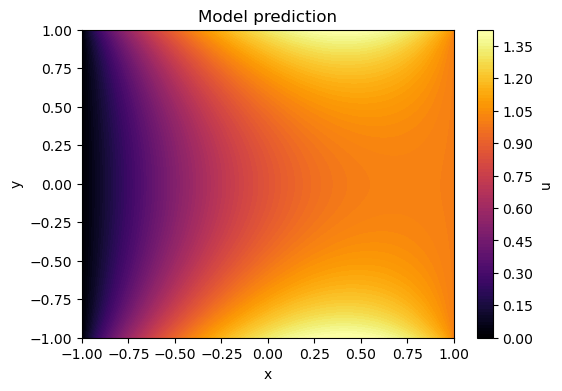

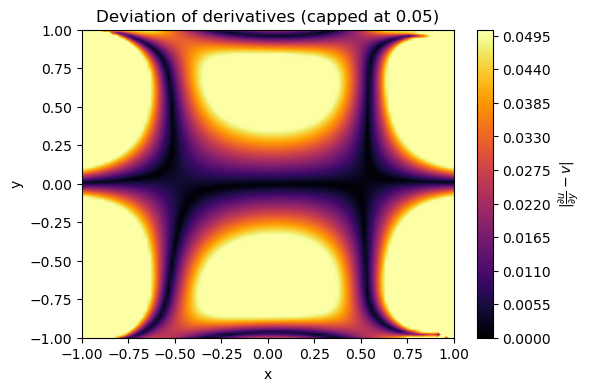

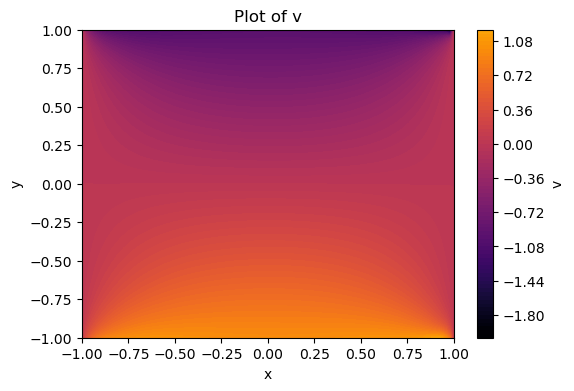

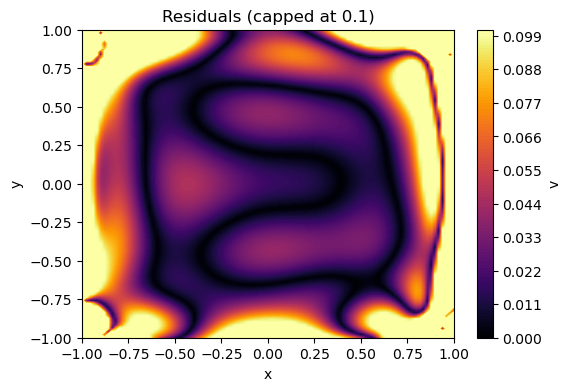

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/heat/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


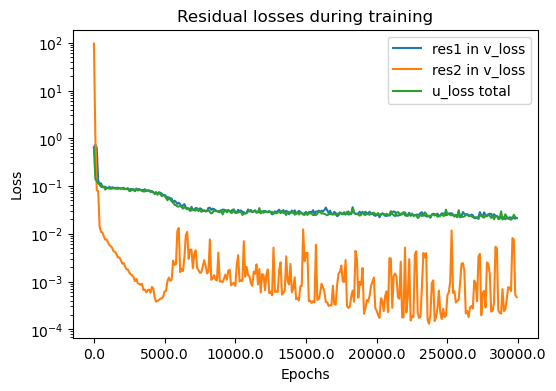

In [9]:
plot_ctx.vmax = 1.4
plot_ctx.vmin = 0
utils.plot_function_on_2d_cube([lambda x: model_u(x)], plot_ctx)

DER_MAX_CAP = 0.05
plot_ctx.vmin = 0.0
plot_ctx.vmax = DER_MAX_CAP
plot_ctx.titles = [f'Deviation of derivatives (capped at {DER_MAX_CAP})']
plot_ctx.function_names = [r'$|\frac{\partial u}{\partial y} - v|$']

# print u's partial derivative by y 
def u_y(x: torch.Tensor):
    x.requires_grad_(True)
    out = model_u(x)
    return calc.dir_derivative(x, out, torch.tensor([0, -1], dtype=torch.float32, device=device), False, True)    

utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(u_y(x) - model_v(x)[:, 1]), 0.0, DER_MAX_CAP)], plot_ctx)

# plot v_2
plot_ctx.vmin = -2
plot_ctx.vmax = 2
plot_ctx.titles=['Plot of v']
plot_ctx.function_names = ['v']
utils.plot_function_on_2d_cube([lambda x: u_y(x)], plot_ctx)


# plot residuals
def dummy_res(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    # PDE ztrata:
    pde_output = model(pde_input)
    #print(u_t)
    laplacian = calc.laplacian(pde_input, pde_output.unsqueeze(1), device=device, time_dependant=False)
    return laplacian


MAX = 0.1
plot_ctx.vmin = 0
plot_ctx.vmax = MAX
plot_ctx.titles = [f'Residuals (capped at {MAX})']
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(dummy_res(x.requires_grad_(True), model_u)), 0.0, MAX)], plot_ctx)


plot_ctx.titles = ['Residual losses during training']
plot_ctx.y_label = 'Loss'
plot_ctx.x_label = 'Epochs'
utils.plot_loss_values({"res1 in v_loss": v_loss_comp[0], "res2 in v_loss": v_loss_comp[1], "u_loss total": u_loss}, plot_ctx)